# 1. Load libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_percentage_error  
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = '../data/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv'
OUT_FILE   = DATA_DIR + 'submission_baseline.csv'

In [2]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


# 2. Feature Engineering

- Generate baseline model, and assess performance of baseline

In [3]:
train_index = train.Date.dt.year < 2021
test_index  = ~train_index

In [4]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day


In [5]:
def generateBase(predictedYear):
    upper = predictedYear - 1
    # ── Fit on 2012–2020 only ────────────────────────────────────────────────────
    train_pre = train[train['year'] <= upper].copy()

    # Seasonal profile
    annual_means_pre = train_pre.groupby('year')[['Revenue', 'COGS']].transform('mean')
    train_pre['rev_norm']  = train_pre['Revenue'] / annual_means_pre['Revenue']
    train_pre['cogs_norm'] = train_pre['COGS']    / annual_means_pre['COGS']

    seasonal_pre = (
        train_pre
        .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
        .mean()
        .reset_index()
    )

    # YoY growth 2013–predicted year
    annual_pre      = train_pre.groupby('year')[['Revenue', 'COGS']].sum()
    full_years_pre  = annual_pre.loc[2013:upper]
    yoy_rev_pre     = full_years_pre['Revenue'].pct_change().dropna()
    yoy_cogs_pre    = full_years_pre['COGS'].pct_change().dropna()
    growth_rev_pre  = (1 + yoy_rev_pre).prod()  ** (1 / len(yoy_rev_pre))
    growth_cogs_pre = (1 + yoy_cogs_pre).prod() ** (1 / len(yoy_cogs_pre))

    # Base level: 2020 (last year before validation window)
    base_rev_pre  = annual_pre.loc[upper, 'Revenue'] / 365
    base_cogs_pre = annual_pre.loc[upper, 'COGS']    / 365

    # ── Predict 2021–2022 (zero leakage) ─────────────────────────────────────────
    val = (train[train['year'].isin([predictedYear])]
        [['Date', 'year', 'month', 'day', 'Revenue', 'COGS']]
        .copy())

    val = val.merge(seasonal_pre, on=['month', 'day'], how='left')
    val['rev_norm']  = val['rev_norm'].fillna(1.0)
    val['cogs_norm'] = val['cogs_norm'].fillna(1.0)
    val['years_ahead'] = val['year'] - upper

    val['Revenue_pred'] = base_rev_pre  * growth_rev_pre**val['years_ahead']  * val['rev_norm']
    val['COGS_pred']    = base_cogs_pre * growth_cogs_pre**val['years_ahead'] * val['cogs_norm']


    return dict(zip(val['Date'], val['Revenue_pred'])), dict(zip(val['Date'], val['COGS_pred']))

In [6]:
# Based on based lines we will predict revenue and COGS for year from 2015 to 2022
# We can not predict for 2013 and 2014, due to insufficient data
years = np.arange(2015, 2023)
train['Revenue_pred'] = np.nan
train['COGS_pred'] = np.nan
revenue_pred = {}
cogs_pred = {}
for year in years:
    rev_pred, cogs_pred = generateBase(year)
    revenue_pred.update(rev_pred)
    cogs_pred.update(cogs_pred)
train['Revenue_pred'] = train['Date'].map(revenue_pred)
train['COGS_pred'] = train['Date'].map(cogs_pred)

## Feature engineering
- Add more times features
- Try to use lag one past year => for no leakage data and utilize past data behavior
- Add promotion data => promotion data operation exactly the same each 2 years so we can easily predict what happen in the year of 2023

In [7]:
# Time features
def create_time_features(df, min_date):
    
    # Tạo bản copy để không sửa dataframe gốc
    df = df.copy()
    
    # Lấy thứ trong tuần
    df["dayofweek"] = df["Date"].dt.dayofweek
    
    
    # Lấy ngày thứ bao nhiêu trong năm
    df["dayofyear"] = df["Date"].dt.dayofyear
    
    
    # Lấy tuần thứ bao nhiêu trong năm
    df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    
   
    
    # Kiểm tra ngày đó có phải ngày cuối tháng không
    df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)
    
    
    # Tạo biến thời gian tính từ ngày đầu tiên trong train
    # Ngày đầu tiên = 0, ngày tiếp theo = 1,...
    # Giúp model học long-term trend
    df["time_idx"] = (df["Date"] - min_date).dt.days
    
    
    # Tạo cyclical features cho tháng
    # Tháng 12 và tháng 1 thực ra gần nhau trong chu kỳ năm
    # Nếu chỉ dùng số 12 và 1 thì model có thể hiểu nhầm là chúng rất xa nhau
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    
    
    # Tạo cyclical features cho thứ trong tuần
    # Chủ nhật và thứ hai cũng gần nhau theo chu kỳ tuần
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
    
    
    # Tạo seasonal features theo năm
    # Các biến này giúp model học pattern lặp lại theo năm
    df["year_sin_1"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["year_cos_1"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)
    
    # Sóng thứ hai để bắt pattern phức tạp hơn một chút
    df["year_sin_2"] = np.sin(4 * np.pi * df["dayofyear"] / 365.25)
    df["year_cos_2"] = np.cos(4 * np.pi * df["dayofyear"] / 365.25)
    
    
    # Trả lại dataframe sau khi thêm feature
    return df

In [8]:
train['Date'].dt.strftime('%Y-%m')

0       2012-07
1       2012-07
2       2012-07
3       2012-07
4       2012-07
         ...   
3828    2022-12
3829    2022-12
3830    2022-12
3831    2022-12
3832    2022-12
Name: Date, Length: 3833, dtype: object

In [9]:
train['rev_residual'] = train['Revenue'] - train['Revenue_pred']
train['COGS_residual'] = train['COGS'] - train['COGS_pred']
train['rev_lag_365'] = train['rev_residual'].shift(365)
train['rev_lag_372'] = train['rev_residual'].shift(372)  # 365 + 7 (1 tuần)
train['COGS_lag_365'] = train['COGS_residual'].shift(365)
train['COGS_lag_372'] = train['COGS_residual'].shift(372)  # 365 + 7 (1 tuần)

train['ym'] = train['Date'].dt.strftime('%Y-%m')
rolling_means = train.groupby('ym')[['Revenue', 'COGS']].mean().reset_index()
train = train.merge(rolling_means, on='ym', how='left', suffixes=('', '_monthly_mean'))

#for not leaking, we will sift 365 days (1 year) for lag features and 7 days for monthly mean features
train['rolling_rev_mean_365'] = train['Revenue_monthly_mean'].shift(365)
train['rolling_rev_mean_372'] = train['Revenue_monthly_mean'].shift(372)
train['rolling_cogs_mean_365'] = train['COGS_monthly_mean'].shift(365)
train['rolling_cogs_mean_372'] = train['COGS_monthly_mean'].shift(372)



In [10]:
promotions = pd.read_csv('../data/promotions.csv', parse_dates=['start_date', 'end_date'])
all_promo_dates = []
for _, row in promotions.iterrows():
    date_range = pd.date_range(row['start_date'], row['end_date'])
    temp_df = pd.DataFrame({
        'Date': date_range,
        'has_promo': 1,
        'promo_discount': row['discount_value'],
        'promo_type_perc': 1 if row['promo_type'] == 'percentage' else 0
    })
    all_promo_dates.append(temp_df)

promo_daily = pd.concat(all_promo_dates).drop_duplicates('Date')

# 3. Fixed Baseline & Feature Engineering

Fix the COGS accumulation bug in the original loop, then rebuild clean feature sets for both Revenue and COGS.

In [11]:
# Rebuild from scratch with correct variable naming (bug: original loop overwrote cogs_pred each iteration)
train_base = train[['Date', 'Revenue', 'COGS']].copy()
train_base['year']        = train_base['Date'].dt.year
train_base['day_of_year'] = train_base['Date'].dt.dayofyear
train_base['month']       = train_base['Date'].dt.month
train_base['day']         = train_base['Date'].dt.day

years = np.arange(2015, 2023)
all_rev_pred  = {}
all_cogs_pred = {}

for year in years:
    rev_p, cogs_p = generateBase(year)
    all_rev_pred.update(rev_p)
    all_cogs_pred.update(cogs_p)

train_base['Revenue_pred'] = train_base['Date'].map(all_rev_pred)
train_base['COGS_pred']    = train_base['Date'].map(all_cogs_pred)

# Validate baseline on 2022
val22 = train_base[train_base['year'] == 2022]
print(f"Baseline MAPE Revenue (2022): {mean_absolute_percentage_error(val22['Revenue'], val22['Revenue_pred']):.4f}")
print(f"Baseline MAPE COGS    (2022): {mean_absolute_percentage_error(val22['COGS'],    val22['COGS_pred']):.4f}")

Baseline MAPE Revenue (2022): 0.2126
Baseline MAPE COGS    (2022): 0.2090


In [12]:
# Residuals and lag features (365 and 372 days)
train_base['rev_residual']  = train_base['Revenue'] - train_base['Revenue_pred']
train_base['cogs_residual'] = train_base['COGS']    - train_base['COGS_pred']

train_base['rev_lag_365']   = train_base['rev_residual'].shift(365)
train_base['rev_lag_372']   = train_base['rev_residual'].shift(372)
train_base['cogs_lag_365']  = train_base['cogs_residual'].shift(365)
train_base['cogs_lag_372']  = train_base['cogs_residual'].shift(372)

# Monthly mean lags (shift 1 year to avoid leakage)
train_base['ym'] = train_base['Date'].dt.strftime('%Y-%m')
ym_means = train_base.groupby('ym')[['Revenue', 'COGS']].mean().reset_index()
train_base = train_base.merge(ym_means, on='ym', how='left', suffixes=('', '_monthly_mean'))
train_base['rolling_rev_mean_365']  = train_base['Revenue_monthly_mean'].shift(365)
train_base['rolling_rev_mean_372']  = train_base['Revenue_monthly_mean'].shift(372)
train_base['rolling_cogs_mean_365'] = train_base['COGS_monthly_mean'].shift(365)
train_base['rolling_cogs_mean_372'] = train_base['COGS_monthly_mean'].shift(372)

print("train_base shape:", train_base.shape)

train_base shape: (3833, 22)


In [13]:
# Time features + promotions
MIN_DATE = train_base['Date'].min()
ml_df2 = create_time_features(train_base, MIN_DATE)
ml_df2 = ml_df2.merge(promo_daily, on='Date', how='left')
ml_df2['has_promo']       = ml_df2['has_promo'].fillna(0)
ml_df2['promo_discount']  = ml_df2['promo_discount'].fillna(0)
ml_df2['promo_type_perc'] = ml_df2['promo_type_perc'].fillna(0)
print("ml_df2 shape:", ml_df2.shape)
ml_df2.head(3)

ml_df2 shape: (3833, 38)


,Date,Revenue,COGS,year,day_of_year,month,day,Revenue_pred,COGS_pred,rev_residual,...,month_cos,dow_sin,dow_cos,year_sin_1,year_cos_1,year_sin_2,year_cos_2,has_promo,promo_discount,promo_type_perc
0,2012-07-04,5123547.94,3982991.19,2012,186,7,4,NaN,NaN,NaN,...,-0.866025,0.974928,-0.222521,-0.058026,-0.998315,0.115856,0.993266,0.0,0.0,0.0
1,2012-07-05,2751773.45,2150580.23,2012,187,7,5,NaN,NaN,NaN,...,-0.866025,0.433884,-0.900969,-0.075190,-0.997169,0.149953,0.988693,0.0,0.0,0.0
2,2012-07-06,3054029.42,2517632.84,2012,188,7,6,NaN,NaN,NaN,...,-0.866025,-0.433884,-0.900969,-0.092331,-0.995728,0.183874,0.982950,0.0,0.0,0.0


# 4. ML Models — Revenue & COGS

Train LightGBM, XGBoost, and CatBoost on the residuals for both targets. Validate on 2022.

In [14]:
BASE_FEATS = [
    'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear',
    'is_month_end', 'time_idx',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'year_sin_1', 'year_cos_1', 'year_sin_2', 'year_cos_2',
    'has_promo', 'promo_discount', 'promo_type_perc',
]
REV_FEATS  = BASE_FEATS + ['Revenue_pred', 'rev_lag_365',  'rev_lag_372',
                            'rolling_rev_mean_365',  'rolling_rev_mean_372']
COGS_FEATS = BASE_FEATS + ['COGS_pred',    'cogs_lag_365', 'cogs_lag_372',
                            'rolling_cogs_mean_365', 'rolling_cogs_mean_372']

ml_rev  = ml_df2.dropna(subset=REV_FEATS  + ['rev_residual']).reset_index(drop=True)
ml_cogs = ml_df2.dropna(subset=COGS_FEATS + ['cogs_residual']).reset_index(drop=True)

def split_xy(df, feat_cols, target):
    tr = df['year'] <= 2021
    va = ~tr
    return (df.loc[tr, feat_cols], df.loc[va, feat_cols],
            df.loc[tr, target],    df.loc[va, target],
            df.loc[va])           # meta for evaluation

Xr_tr, Xr_va, yr_tr, yr_va, meta_rev  = split_xy(ml_rev,  REV_FEATS,  'rev_residual')
Xc_tr, Xc_va, yc_tr, yc_va, meta_cogs = split_xy(ml_cogs, COGS_FEATS, 'cogs_residual')

print(f"Revenue  — train: {Xr_tr.shape}  val: {Xr_va.shape}")
print(f"COGS     — train: {Xc_tr.shape}  val: {Xc_va.shape}")

Revenue  — train: (2185, 24)  val: (365, 24)
COGS     — train: (2185, 24)  val: (365, 24)


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

def eval_model(name, target, baseline, resid_pred, actual):
    final = baseline.values + resid_pred
    mape      = mean_absolute_percentage_error(actual.values, final)
    rmse      = np.sqrt(mean_squared_error(actual.values, final))
    mae       = mean_absolute_error(actual.values, final)
    r2        = r2_score(actual.values, final)
    base_mape = mean_absolute_percentage_error(actual.values, baseline.values)
    print(f"  {name:35s}  base={base_mape:.4f}  mape={mape:.4f}  rmse={rmse:,.0f}  mae={mae:,.0f}  r2={r2:.4f}")
    results[name] = {'mape': mape, 'rmse': rmse, 'mae': mae, 'r2': r2}
    return final

In [16]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

lgbm_params = dict(
    n_estimators=2000, learning_rate=0.03, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1,
)
cb = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

print("── LightGBM ──────────────────────────────────────────────────────")
lgbm_rev_m = LGBMRegressor(**lgbm_params)
lgbm_rev_m.fit(Xr_tr, yr_tr, eval_set=[(Xr_va, yr_va)], callbacks=cb)
eval_model("LightGBM  Revenue", "Revenue", meta_rev['Revenue_pred'],
           lgbm_rev_m.predict(Xr_va), meta_rev['Revenue'])

lgbm_cogs_m = LGBMRegressor(**lgbm_params)
lgbm_cogs_m.fit(Xc_tr, yc_tr, eval_set=[(Xc_va, yc_va)], callbacks=cb)
eval_model("LightGBM  COGS",    "COGS",    meta_cogs['COGS_pred'],
           lgbm_cogs_m.predict(Xc_va), meta_cogs['COGS'])

── LightGBM ──────────────────────────────────────────────────────
  LightGBM  Revenue                    base=0.2126  mape=0.2016  rmse=834,636  mae=617,368  r2=0.7514
  LightGBM  COGS                       base=0.2090  mape=0.2098  rmse=686,759  mae=507,120  r2=0.7783


array([2229349.45396532,  931656.7370743 ,  729805.60769845,
        891284.37246935,  947884.82058184, 1004771.18863899,
       1019379.93004039,  930982.24515178, 1014516.31412762,
       1169878.27248765, 1340327.46839721, 1341735.635704  ,
       1473398.91950904, 1222459.5784414 , 1141887.44049778,
       1136144.96416634, 1494902.76311025, 1822004.23296496,
       1719634.92473904, 1437162.50924173, 1430621.29098314,
       1294685.6147817 , 1415939.44320999, 1599290.65084679,
       2057868.83028911, 2179219.6538788 , 2124070.24198895,
       2420848.72726435, 2415482.55313561, 2470086.32636274,
       2381733.25169711, 2081779.1326349 , 1526802.31607644,
       1148920.42024464, 1166584.25999939, 1262739.19834787,
       1277239.79161495, 1433500.41275708, 1393400.74601697,
       1479475.68185773, 1674321.98895227, 1687344.91736851,
       1701345.09344141, 1653902.73335819, 2445019.6784412 ,
       2143113.56207595, 2029555.25385465, 2196494.54336301,
       2082416.7471256 ,

In [17]:
from xgboost import XGBRegressor

xgb_params = dict(
    n_estimators=2000, learning_rate=0.03, max_depth=6,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1,
    early_stopping_rounds=50, verbosity=0,
)

print("── XGBoost ───────────────────────────────────────────────────────")
xgb_rev_m = XGBRegressor(**xgb_params)
xgb_rev_m.fit(Xr_tr, yr_tr, eval_set=[(Xr_va, yr_va)], verbose=False)
eval_model("XGBoost   Revenue", "Revenue", meta_rev['Revenue_pred'],
           xgb_rev_m.predict(Xr_va), meta_rev['Revenue'])

xgb_cogs_m = XGBRegressor(**xgb_params)
xgb_cogs_m.fit(Xc_tr, yc_tr, eval_set=[(Xc_va, yc_va)], verbose=False)
eval_model("XGBoost   COGS",    "COGS",    meta_cogs['COGS_pred'],
           xgb_cogs_m.predict(Xc_va), meta_cogs['COGS'])

── XGBoost ───────────────────────────────────────────────────────
  XGBoost   Revenue                    base=0.2126  mape=0.1952  rmse=793,483  mae=584,437  r2=0.7753
  XGBoost   COGS                       base=0.2090  mape=0.2099  rmse=685,251  mae=505,752  r2=0.7793


array([2139757.28980549,  891694.72565437,  727413.81694444,
        933079.49414027,  931925.72050805,  999518.91790202,
       1001774.19096287,  991696.37664711, 1111350.73102937,
       1190191.59914108, 1398187.84158958, 1421307.43973964,
       1568790.71203998, 1161574.1810374 , 1139512.37984998,
       1185510.8189273 , 1498759.47166368, 1652168.81107664,
       1610732.36488788, 1412340.20767831, 1403318.45311305,
       1294466.22804145, 1477378.96515486, 1695019.6387856 ,
       1990383.13280991, 2125024.79452176, 2230504.60192186,
       2481758.13577659, 2337933.71488486, 2289896.3861955 ,
       2253159.57625038, 1985259.35694216, 1367220.17529826,
       1245248.04533807, 1213977.43075146, 1341775.93330075,
       1341388.92589607, 1494711.07400852, 1426738.6279539 ,
       1492304.03393744, 1843297.4147603 , 1827289.20918421,
       1628022.23658895, 1737536.46951646, 2385265.71570129,
       2074030.61670312, 2063822.84552502, 2367097.12912735,
       2131909.33711792,

In [18]:
from catboost import CatBoostRegressor

cat_params = dict(
    iterations=2000, learning_rate=0.03, depth=6,
    l2_leaf_reg=3, subsample=0.8, random_seed=42,
    early_stopping_rounds=50, verbose=0,
)

print("── CatBoost ──────────────────────────────────────────────────────")
cat_rev_m = CatBoostRegressor(**cat_params)
cat_rev_m.fit(Xr_tr, yr_tr, eval_set=(Xr_va, yr_va))
eval_model("CatBoost  Revenue", "Revenue", meta_rev['Revenue_pred'],
           cat_rev_m.predict(Xr_va), meta_rev['Revenue'])

cat_cogs_m = CatBoostRegressor(**cat_params)
cat_cogs_m.fit(Xc_tr, yc_tr, eval_set=(Xc_va, yc_va))
eval_model("CatBoost  COGS",    "COGS",    meta_cogs['COGS_pred'],
           cat_cogs_m.predict(Xc_va), meta_cogs['COGS'])

── CatBoost ──────────────────────────────────────────────────────
  CatBoost  Revenue                    base=0.2126  mape=0.1875  rmse=756,828  mae=557,857  r2=0.7956
  CatBoost  COGS                       base=0.2090  mape=0.2061  rmse=649,249  mae=478,426  r2=0.8019


array([2174362.84263165,  791628.32314657,  819394.8172283 ,
        943179.69589686, 1015953.71399299, 1136061.80149808,
       1040913.30369214,  950018.45744901, 1107952.58247006,
       1284556.26948385, 1478414.68171495, 1351114.71130383,
       1494160.73358763, 1217549.12300814, 1164944.59440797,
       1269696.12356558, 1542898.87453864, 1621345.99020927,
       1537316.67859527, 1490926.9199689 , 1433030.80972741,
       1352199.50271456, 1532608.73338216, 1744219.50010584,
       1925686.94268323, 2086552.9408427 , 2171056.81634972,
       2373920.56704347, 2348675.73348007, 2357495.96076092,
       2201052.56693186, 1836841.9863632 , 1321343.51715898,
       1212664.0505255 , 1269744.44286125, 1352553.3683488 ,
       1407105.67559308, 1628866.96369107, 1598991.76958721,
       1651455.87512595, 1890797.10992544, 1793801.71819026,
       1742652.64091347, 1931156.49187694, 2362637.24116016,
       2140852.67647487, 2137427.70286497, 2299488.01045779,
       2114793.71056619,

In [19]:
models = ['LightGBM', 'XGBoost', 'CatBoost']
keys   = {
    'LightGBM': ('LightGBM  Revenue', 'LightGBM  COGS'),
    'XGBoost':  ('XGBoost   Revenue', 'XGBoost   COGS'),
    'CatBoost': ('CatBoost  Revenue', 'CatBoost  COGS'),
}

rows = []
for m in models:
    rk, ck = keys[m]
    for target, k in [('Revenue', rk), ('COGS', ck)]:
        rows.append({
            'Model':  m,
            'Target': target,
            'RMSE':   results[k]['rmse'],
            'MAE':    results[k]['mae'],
            'MAPE':   results[k]['mape'],
            'R²':     results[k]['r2'],
        })

cmp = pd.DataFrame(rows)
cmp['RMSE']  = cmp['RMSE'].map('{:,.0f}'.format)
cmp['MAE']   = cmp['MAE'].map('{:,.0f}'.format)
cmp['MAPE']  = cmp['MAPE'].map('{:.4f}'.format)
cmp['R²']    = cmp['R²'].map('{:.4f}'.format)
print(cmp.to_string(index=False))

# Best model by average MAPE across both targets
avg_mape = {m: (results[keys[m][0]]['mape'] + results[keys[m][1]]['mape']) / 2 for m in models}
best_model_name = min(avg_mape, key=avg_mape.get)
print(f"\nBest model by avg MAPE: {best_model_name}  ({avg_mape[best_model_name]:.4f})")

   Model  Target    RMSE     MAE   MAPE     R²
LightGBM Revenue 834,636 617,368 0.2016 0.7514
LightGBM    COGS 686,759 507,120 0.2098 0.7783
 XGBoost Revenue 793,483 584,437 0.1952 0.7753
 XGBoost    COGS 685,251 505,752 0.2099 0.7793
CatBoost Revenue 756,828 557,857 0.1875 0.7956
CatBoost    COGS 649,249 478,426 0.2061 0.8019

Best model by avg MAPE: CatBoost  (0.1968)


# 5. Hyperparameter Tuning (Optuna — CatBoost)

Tune CatBoost on both Revenue and COGS residuals using 50 Optuna trials each.

In [20]:
from sklearn.metrics import root_mean_squared_error

In [21]:
import optuna
from catboost import CatBoostRegressor
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_cat_objective(X_tr, y_tr, X_va, y_va, baseline_va, actual_va):
    def objective(trial):
        params = dict(
            iterations        = trial.suggest_int('iterations', 300, 3000),
            learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            depth             = trial.suggest_int('depth', 4, 10),
            l2_leaf_reg       = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            subsample         = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            random_seed=42, verbose=0,
        )
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr)
        return root_mean_squared_error(actual_va.values,
                                              baseline_va.values + m.predict(X_va))
    return objective

print("Tuning CatBoost — Revenue …")
study_rev = optuna.create_study(direction='minimize')
study_rev.optimize(make_cat_objective(Xr_tr, yr_tr, Xr_va, yr_va,
                                      meta_rev['Revenue_pred'], meta_rev['Revenue']),
                   n_trials=50, show_progress_bar=True)
print(f"  Best Revenue MAPE: {study_rev.best_value:.4f}")

print("Tuning CatBoost — COGS …")
study_cogs = optuna.create_study(direction='minimize')
study_cogs.optimize(make_cat_objective(Xc_tr, yc_tr, Xc_va, yc_va,
                                       meta_cogs['COGS_pred'], meta_cogs['COGS']),
                    n_trials=50, show_progress_bar=True)
print(f"  Best COGS MAPE:    {study_cogs.best_value:.4f}")

Tuning CatBoost — Revenue …


Best trial: 7. Best value: 751127:  20%|██        | 10/50 [00:37<02:30,  3.76s/it]


[W 2026-04-30 00:26:04,104] Trial 10 failed with parameters: {'iterations': 2988, 'learning_rate': 0.01974636505267576, 'depth': 10, 'l2_leaf_reg': 1.2301629526268192, 'subsample': 0.5119746527516573, 'colsample_bylevel': 0.6969078809030412} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/home/duong/miniconda3/envs/vscode-test/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_685829/3232436724.py", line 17, in objective
    m.fit(X_tr, y_tr)
  File "/home/duong/miniconda3/envs/vscode-test/lib/python3.10/site-packages/catboost/core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
  File "/home/duong/miniconda3/envs/vscode-test/lib/python3.10/site-packages/catboost/core.py", line 2716, in _fit
    self._train(
  File "/home/duong/miniconda3/

KeyboardInterrupt: 

In [ ]:
# Train final models on training set (≤2021) with tuned params
best_rev_m = CatBoostRegressor(**{**study_rev.best_params, 'random_seed': 42, 'verbose': 0})
best_rev_m.fit(Xr_tr, yr_tr)

best_cogs_m = CatBoostRegressor(**{**study_cogs.best_params, 'random_seed': 42, 'verbose': 0})
best_cogs_m.fit(Xc_tr, yc_tr)

print("── Tuned CatBoost (final validation) ────────────────────────────")
eval_model("Tuned CatBoost Revenue", "Revenue", meta_rev['Revenue_pred'],
           best_rev_m.predict(Xr_va),  meta_rev['Revenue'])
eval_model("Tuned CatBoost COGS",    "COGS",    meta_cogs['COGS_pred'],
           best_cogs_m.predict(Xc_va), meta_cogs['COGS'])

── Tuned CatBoost (final validation) ────────────────────────────
  Tuned CatBoost Revenue               base=0.2126  mape=0.1851  rmse=742,303  mae=544,839  r2=0.8033
  Tuned CatBoost COGS                  base=0.2090  mape=0.2069  rmse=643,244  mae=477,519  r2=0.8055


array([2249542.64797812,  952473.63529439,  836913.95281791,
        923297.25672352,  974800.05621815, 1082542.69203458,
       1096387.53897324,  976368.69218574, 1145648.19281081,
       1324372.82037221, 1474778.93747256, 1363838.82339096,
       1439750.75749229, 1188021.07737753, 1175840.555641  ,
       1316882.0644347 , 1580080.00383662, 1579009.12172841,
       1507960.70961409, 1492889.98925717, 1456128.93957333,
       1383504.28628656, 1612299.62053058, 1840282.87154731,
       1919233.85161176, 2059225.32356187, 2093932.18992255,
       2312810.75424874, 2377100.13976318, 2478257.22197883,
       2346718.15574326, 1896397.23686979, 1345341.21817627,
       1156883.51327102, 1212777.95077664, 1404198.59051712,
       1376959.60501961, 1678716.97052314, 1645327.43147231,
       1695909.2143751 , 1906876.08812322, 1868150.18552073,
       1840344.11386127, 2009701.21451961, 2411557.26756153,
       2069671.58882683, 2184184.83692512, 2357921.52201116,
       2165216.30713737,

# 6. Submission Predictions

1. Retrain on **all** available data (2015–2022).  
2. Generate baseline predictions for 2023–2024.  
3. Iteratively predict residuals: 2023 first (lags come from 2022 actuals), then 2024 (lags come from 2023 predictions).  
4. Save submission.

In [ ]:
# Retrain on all years (2015–2022) — no need to hold out 2022 for validation anymore
X_all_rev  = ml_rev[REV_FEATS]
y_all_rev  = ml_rev['rev_residual']
X_all_cogs = ml_cogs[COGS_FEATS]
y_all_cogs = ml_cogs['cogs_residual']

final_rev_m = CatBoostRegressor(**{**study_rev.best_params, 'random_seed': 42, 'verbose': 0})
final_rev_m.fit(X_all_rev, y_all_rev)

final_cogs_m = CatBoostRegressor(**{**study_cogs.best_params, 'random_seed': 42, 'verbose': 0})
final_cogs_m.fit(X_all_cogs, y_all_cogs)

print(f"Final models trained on {len(X_all_rev)} revenue rows and {len(X_all_cogs)} COGS rows.")

Final models trained on 2550 revenue rows and 2550 COGS rows.


In [ ]:
def generate_baseline_future(dates_df, train_df, upper=2022):
    """Baseline predictions for dates outside training range."""
    tr = train_df[train_df['year'] <= upper].copy()
    annual_means = tr.groupby('year')[['Revenue', 'COGS']].transform('mean')
    tr['rev_norm']  = tr['Revenue'] / annual_means['Revenue']
    tr['cogs_norm'] = tr['COGS']    / annual_means['COGS']
    seasonal = tr.groupby(['month', 'day'])[['rev_norm', 'cogs_norm']].mean().reset_index()

    annual   = tr.groupby('year')[['Revenue', 'COGS']].sum()
    fy       = annual.loc[2013:upper]
    gr_rev   = (1 + fy['Revenue'].pct_change().dropna())
    gr_cogs  = (1 + fy['COGS'].pct_change().dropna())
    g_rev    = gr_rev.prod()  ** (1 / len(gr_rev))
    g_cogs   = gr_cogs.prod() ** (1 / len(gr_cogs))

    base_rev  = annual.loc[upper, 'Revenue'] / 365
    base_cogs = annual.loc[upper, 'COGS']    / 365

    df = dates_df.copy()
    df = df.merge(seasonal, on=['month', 'day'], how='left')
    df['rev_norm']  = df['rev_norm'].fillna(1.0)
    df['cogs_norm'] = df['cogs_norm'].fillna(1.0)
    df['years_ahead'] = df['year'] - upper
    df['Revenue_pred'] = base_rev  * g_rev**df['years_ahead']  * df['rev_norm']
    df['COGS_pred']    = base_cogs * g_cogs**df['years_ahead'] * df['cogs_norm']
    return df[['Date', 'Revenue_pred', 'COGS_pred']]

# Build test skeleton
sub = test[['Date']].copy()
sub['year']  = sub['Date'].dt.year
sub['month'] = sub['Date'].dt.month
sub['day']   = sub['Date'].dt.day

sub_base = generate_baseline_future(sub, train_base, upper=2022)
print("Test baseline preview:")
print(sub_base.head())

Test baseline preview:
        Date  Revenue_pred     COGS_pred
0 2023-01-01  2.665507e+06  2.518885e+06
1 2023-01-02  1.280008e+06  1.136463e+06
2 2023-01-03  1.015900e+06  8.227211e+05
3 2023-01-04  1.142997e+06  9.145542e+05
4 2023-01-05  1.236312e+06  9.843902e+05


In [ ]:
promotions = pd.read_csv('../data/promotions.csv', parse_dates=['start_date', 'end_date'])
all_promo_dates = []
for _, row in promotions.iterrows():
    date_range = pd.date_range(row['start_date'], row['end_date'])
    temp_df = pd.DataFrame({
        'Date': date_range,
        'has_promo': 1,
        'promo_discount': row['discount_value'],
        'promo_type_perc': 1 if row['promo_type'] == 'percentage' else 0
    })
    all_promo_dates.append(temp_df)

promo_daily = pd.concat(all_promo_dates).drop_duplicates('Date')

In [ ]:
promotions = promotions[promotions['start_date'].dt.year == 2021]
promotions['start_date'] = promotions['start_date'] + pd.DateOffset(years=2)
promotions['end_date']   = promotions['end_date']   + pd.DateOffset(years=2)

In [ ]:
all_promo_dates = []
for _, row in promotions.iterrows():
    date_range = pd.date_range(row['start_date'], row['end_date'])
    temp_df = pd.DataFrame({
        'Date': date_range,
        'has_promo': 1,
        'promo_discount': row['discount_value'],
        'promo_type_perc': 1 if row['promo_type'] == 'percentage' else 0
    })
    all_promo_dates.append(temp_df)

promo_daily = pd.concat(all_promo_dates).drop_duplicates('Date')

In [ ]:
# Build residual + monthly-mean lookup dicts from training data
rev_resid_map  = dict(zip(ml_df2['Date'], ml_df2['rev_residual']))
cogs_resid_map = dict(zip(ml_df2['Date'], ml_df2['cogs_residual']))
ym_rev_map  = ml_df2.groupby('ym')['Revenue'].mean().to_dict()
ym_cogs_map = ml_df2.groupby('ym')['COGS'].mean().to_dict()

def add_lag_features(df, rev_map, cogs_map, ym_rev, ym_cogs):
    """Compute lag-365/372 features from lookup dicts."""
    def lag(d, n, m):   return m.get(d - pd.Timedelta(days=n), 0.0)
    def lag_ym(d, n, m): return m.get((d - pd.Timedelta(days=n)).strftime('%Y-%m'), 0.0)
    df = df.copy()
    df['rev_lag_365']   = df['Date'].apply(lambda d: lag(d, 365, rev_map))
    df['rev_lag_372']   = df['Date'].apply(lambda d: lag(d, 372, rev_map))
    df['cogs_lag_365']  = df['Date'].apply(lambda d: lag(d, 365, cogs_map))
    df['cogs_lag_372']  = df['Date'].apply(lambda d: lag(d, 372, cogs_map))
    df['rolling_rev_mean_365']  = df['Date'].apply(lambda d: lag_ym(d, 365, ym_rev))
    df['rolling_rev_mean_372']  = df['Date'].apply(lambda d: lag_ym(d, 372, ym_rev))
    df['rolling_cogs_mean_365'] = df['Date'].apply(lambda d: lag_ym(d, 365, ym_cogs))
    df['rolling_cogs_mean_372'] = df['Date'].apply(lambda d: lag_ym(d, 372, ym_cogs))
    return df

# Merge baseline into sub skeleton
sub_full = sub.merge(sub_base, on='Date')
sub_full = create_time_features(sub_full, MIN_DATE)
sub_full = sub_full.merge(promo_daily, on='Date', how='left')
sub_full['has_promo']       = sub_full['has_promo'].fillna(0)
sub_full['promo_discount']  = sub_full['promo_discount'].fillna(0)
sub_full['promo_type_perc'] = sub_full['promo_type_perc'].fillna(0)

print("sub_full shape:", sub_full.shape)

sub_full shape: (548, 22)


In [ ]:
# ── Pass 1: predict 2023 (lags from 2022 actuals) ──────────────────────────
sub_2023 = add_lag_features(
    sub_full[sub_full['year'] == 2023].copy(),
    rev_resid_map, cogs_resid_map, ym_rev_map, ym_cogs_map
)

pred_rev_2023  = sub_2023['Revenue_pred'] + final_rev_m.predict(sub_2023[REV_FEATS])
pred_cogs_2023 = sub_2023['COGS_pred']    + final_cogs_m.predict(sub_2023[COGS_FEATS])

# Store 2023 predicted residuals for use as 2024 lags
for date, rv, cg in zip(sub_2023['Date'], pred_rev_2023 - sub_2023['Revenue_pred'],
                                          pred_cogs_2023 - sub_2023['COGS_pred']):
    rev_resid_map[date]  = rv
    cogs_resid_map[date] = cg

# Update monthly means with 2023 predicted values
ym_2023 = pd.DataFrame({'Date': sub_2023['Date'].values,
                         'Revenue': pred_rev_2023.values,
                         'COGS':    pred_cogs_2023.values})
ym_2023['ym'] = ym_2023['Date'].dt.strftime('%Y-%m')
ym_rev_map.update(ym_2023.groupby('ym')['Revenue'].mean().to_dict())
ym_cogs_map.update(ym_2023.groupby('ym')['COGS'].mean().to_dict())

print(f"2023 predictions computed. Rev mean: {pred_rev_2023.mean():,.0f}, COGS mean: {pred_cogs_2023.mean():,.0f}")

# ── Pass 2: predict 2024 (lags from 2023 predictions) ──────────────────────
sub_2024 = add_lag_features(
    sub_full[sub_full['year'] == 2024].copy(),
    rev_resid_map, cogs_resid_map, ym_rev_map, ym_cogs_map
)

pred_rev_2024  = sub_2024['Revenue_pred'] + final_rev_m.predict(sub_2024[REV_FEATS])
pred_cogs_2024 = sub_2024['COGS_pred']    + final_cogs_m.predict(sub_2024[COGS_FEATS])

print(f"2024 predictions computed. Rev mean: {pred_rev_2024.mean():,.0f}, COGS mean: {pred_cogs_2024.mean():,.0f}")

2023 predictions computed. Rev mean: 3,448,130, COGS mean: 2,982,720
2024 predictions computed. Rev mean: 4,020,816, COGS mean: 3,336,608


In [ ]:
promo_daily

,Date,has_promo,promo_discount,promo_type_perc
0,2013-03-18,1,12.0,1
1,2013-03-19,1,12.0,1
2,2013-03-20,1,12.0,1
3,2013-03-21,1,12.0,1
4,2013-03-22,1,12.0,1
...,...,...,...,...
39,2022-12-27,1,20.0,1
40,2022-12-28,1,20.0,1
41,2022-12-29,1,20.0,1
42,2022-12-30,1,20.0,1


In [ ]:
# Assemble final submission
submission = pd.concat([
    pd.DataFrame({'Date': sub_2023['Date'].values, 'Revenue': pred_rev_2023.values,  'COGS': pred_cogs_2023.values}),
    pd.DataFrame({'Date': sub_2024['Date'].values, 'Revenue': pred_rev_2024.values,  'COGS': pred_cogs_2024.values}),
], ignore_index=True).sort_values('Date').reset_index(drop=True)

submission.to_csv(DATA_DIR + 'submission_improved.csv', index=False)
print(f"Saved → {DATA_DIR}submission_improved.csv  ({len(submission)} rows)")
submission.head(10)

Saved → ../data/submission_improved.csv  (548 rows)


,Date,Revenue,COGS
0,2023-01-01,2.912014e+06,2.574289e+06
1,2023-01-02,1.601769e+06,1.271878e+06
2,2023-01-03,1.363167e+06,9.001002e+05
3,2023-01-04,1.282732e+06,9.204857e+05
4,2023-01-05,1.597732e+06,1.047547e+06
5,2023-01-06,1.619604e+06,1.071086e+06
6,2023-01-07,1.802785e+06,1.338789e+06
7,2023-01-08,2.021767e+06,1.468901e+06
8,2023-01-09,2.207722e+06,1.630342e+06
9,2023-01-10,2.110931e+06,1.555261e+06


Submission MAPE Revenue : 0.1615
Submission MAPE COGS    : 0.1403
Submission MAPE Average : 0.1509


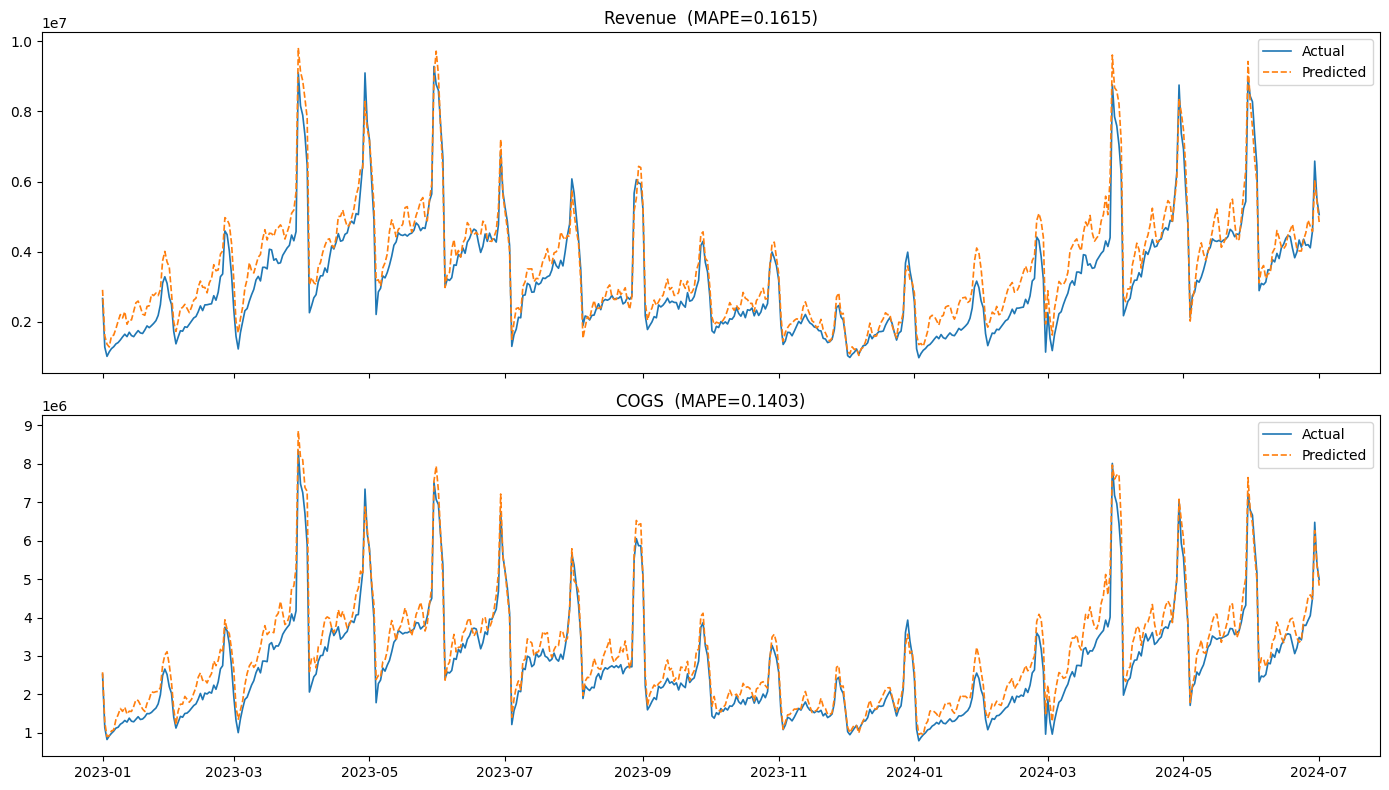

In [ ]:
# Evaluate against sample_submission (which contains ground truth)
gt = pd.read_csv(TEST_FILE, parse_dates=['Date'])
merged = submission.merge(gt, on='Date', suffixes=('_pred', '_actual'))

mape_rev_sub  = mean_absolute_percentage_error(merged['Revenue_actual'], merged['Revenue_pred'])
mape_cogs_sub = mean_absolute_percentage_error(merged['COGS_actual'],    merged['COGS_pred'])
print(f"Submission MAPE Revenue : {mape_rev_sub:.4f}")
print(f"Submission MAPE COGS    : {mape_cogs_sub:.4f}")
print(f"Submission MAPE Average : {(mape_rev_sub + mape_cogs_sub) / 2:.4f}")

# Plot predictions vs actuals
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, pred_col, act_col, title in [
    (axes[0], 'Revenue_pred', 'Revenue_actual', 'Revenue'),
    (axes[1], 'COGS_pred',    'COGS_actual',    'COGS'),
]:
    ax.plot(merged['Date'], merged[act_col],  label='Actual',     lw=1.2)
    ax.plot(merged['Date'], merged[pred_col], label='Predicted',  lw=1.2, linestyle='--')
    ax.set_title(f'{title}  (MAPE={mean_absolute_percentage_error(merged[act_col], merged[pred_col]):.4f})')
    ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()